In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
CONFIG = {
    "input_csv": "/kaggle/input/datasets/mishbhaul/arabic-eng-train-dataset/train.csv",        # path to your training data
    "source_col": "en",          # name of source text column
    "target_col": "ar",          # name of target text column
    "output_dir": "outputs",         # where CSVs & charts will be saved
    "top_n": 20                      # how many top words to show in charts
}

In [3]:
def tokenize(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    tokens = text.split()
    return tokens

def compute_term_frequency(series, column_name):
    all_tokens = []
    for text in series:
        all_tokens.extend(tokenize(text))
    counter = Counter(all_tokens)

    freq_df = pd.DataFrame(counter.items(), columns=["Term", "Frequency"])
    freq_df = freq_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
 
    print(f"[{column_name}] Total tokens: {len(all_tokens)} | Unique words: {len(freq_df)}")
    return freq_df

def save_csv(freq_df, output_dir, filename):
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, filename)
    freq_df.to_csv(path, index=False)
    print(f"Saved -> {path}")
    return path

# **VISUALIZATIONS**

In [13]:
def plot_comparison_top_words(freq_df_1, name_1, freq_df_2, name_2, output_dir, top_n=20):
    """Top-N word bar charts for two columns, side by side, for easy comparison."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    for ax, freq_df, name, color in [
        (axes[0], freq_df_1, name_1, "steelblue"),
        (axes[1], freq_df_2, name_2, "indianred"),
    ]:
        top_words = freq_df.head(top_n)
        ax.barh(top_words["Term"][::-1], top_words["Frequency"][::-1], color=color)
        ax.set_title(f"Top {top_n} Words - {name}")
        ax.set_xlabel("Frequency")
        ax.set_ylabel("Term")
 
    plt.tight_layout()
    path = os.path.join(output_dir, f"comparison_top_words_{name_1}_vs_{name_2}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved comparison chart -> {path}")

def plot_comparison_word_length(freq_df_1, name_1, freq_df_2, name_2, output_dir):
    """Word length distribution for two columns, side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
 
    for ax, freq_df, name, color in [
        (axes[0], freq_df_1, name_1, "seagreen"),
        (axes[1], freq_df_2, name_2, "darkorange"),
    ]:
        word_lengths = freq_df["Term"].astype(str).apply(len)
        ax.hist(word_lengths, bins=30, color=color, edgecolor="black")
        ax.set_title(f"Word Length Distribution - {name}")
        ax.set_xlabel("Word Length (characters)")
        ax.set_ylabel("Count of Unique Words")
 
    plt.tight_layout()
    path = os.path.join(output_dir, f"comparison_word_length_{name_1}_vs_{name_2}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved comparison chart -> {path}")

def plot_comparison_frequency_curve(freq_df_1, name_1, freq_df_2, name_2, output_dir):
    plt.figure(figsize=(9, 6))
    plt.plot(freq_df_1["Frequency"].values, color="steelblue", label=name_1)
    plt.plot(freq_df_2["Frequency"].values, color="indianred", label=name_2)
    plt.title(f"Frequency Drop-off Curve: {name_1} vs {name_2}")
    plt.xlabel("Word Rank (0 = most frequent)")
    plt.ylabel("Frequency")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
 
    path = os.path.join(output_dir, f"comparison_frequency_curve_{name_1}_vs_{name_2}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved comparison chart -> {path}")

def compare_columns(results, col_1, col_2, output_dir, top_n):
    print(f"\n--- Comparing columns: {col_1} vs {col_2} ---")
    freq_df_1, freq_df_2 = results[col_1], results[col_2]
 
    plot_comparison_top_words(freq_df_1, col_1, freq_df_2, col_2, output_dir, top_n)
    plot_comparison_word_length(freq_df_1, col_1, freq_df_2, col_2, output_dir)
    plot_comparison_frequency_curve(freq_df_1, col_1, freq_df_2, col_2, output_dir)

# *Analysis : One column at a time*

In [7]:
def analyze_column(df, col_name, output_dir, top_n):
    print(f"\n--- Analyzing column: {col_name} ---")
    freq_df = compute_term_frequency(df[col_name], col_name)
 
    save_csv(freq_df, output_dir, f"term_frequency_{col_name}.csv")
 
    plot_top_words(freq_df, col_name, output_dir, top_n)
    plot_word_length_distribution(freq_df, col_name, output_dir)
    plot_frequency_curve(freq_df, col_name, output_dir)
 
    return freq_df

# **Run**

In [9]:
def main(config):
    print("Loading data...")
    df = pd.read_csv(config["input_csv"])
 
    print(f"Rows loaded: {len(df)}")
    print(f"Columns found: {list(df.columns)}")
 
    results = {}
    for col in [config["source_col"], config["target_col"]]:
        if col not in df.columns:
            print(f"WARNING: column '{col}' not found in dataframe. Skipping.")
            continue
        freq_df = compute_term_frequency(df[col], col)
        save_csv(freq_df, config["output_dir"], f"term_frequency_{col}.csv")
        results[col] = freq_df
 
    # Generate side-by-side comparison charts (only if both columns were found)
    if config["source_col"] in results and config["target_col"] in results:
        compare_columns(
            results,
            config["source_col"],
            config["target_col"],
            config["output_dir"],
            config["top_n"],
        )
 
    print("\nAll done! Check the outputs folder for CSVs and charts.")
    return results

Loading data...
Rows loaded: 21000
Columns found: ['split', 'en', 'ar']
[en] Total tokens: 670845 | Unique words: 53325
Saved -> outputs/term_frequency_en.csv
[ar] Total tokens: 558133 | Unique words: 98062
Saved -> outputs/term_frequency_ar.csv

--- Comparing columns: en vs ar ---


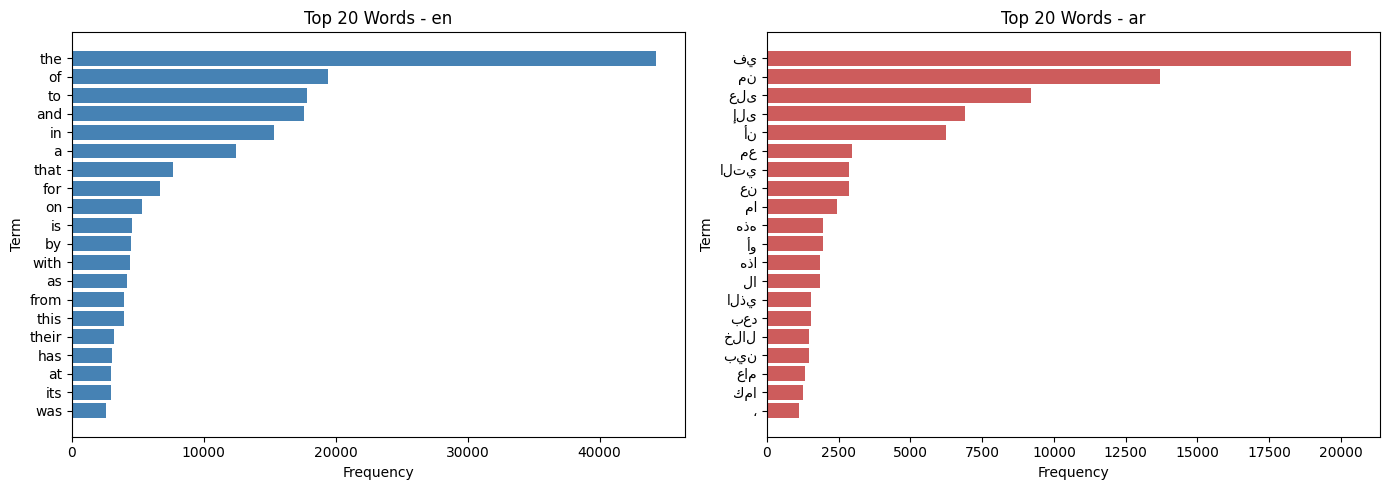

Saved comparison chart -> outputs/comparison_top_words_en_vs_ar.png


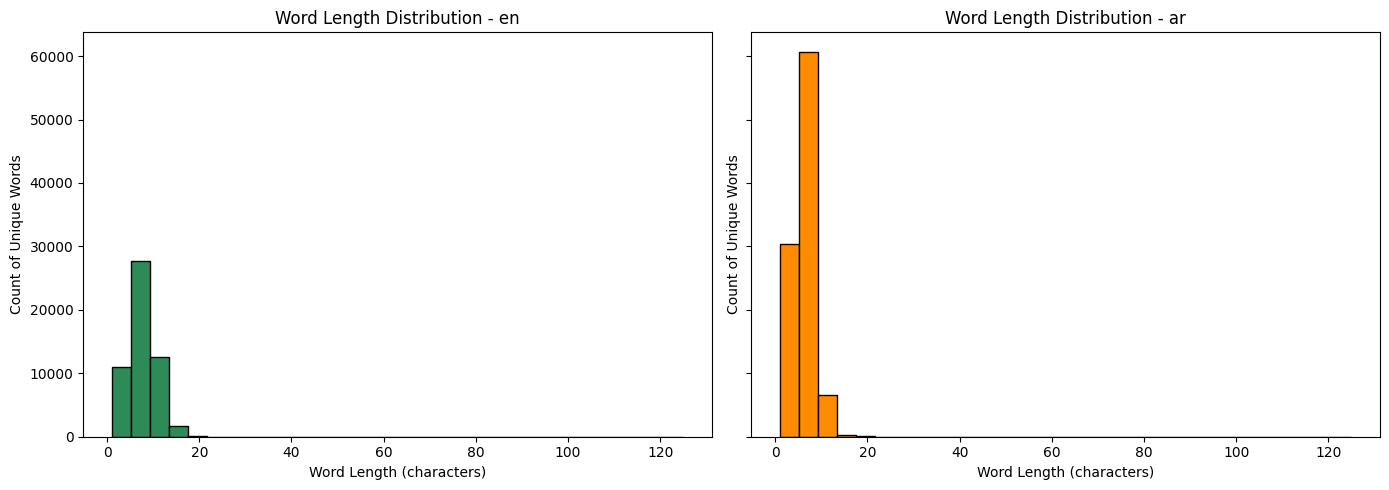

Saved comparison chart -> outputs/comparison_word_length_en_vs_ar.png


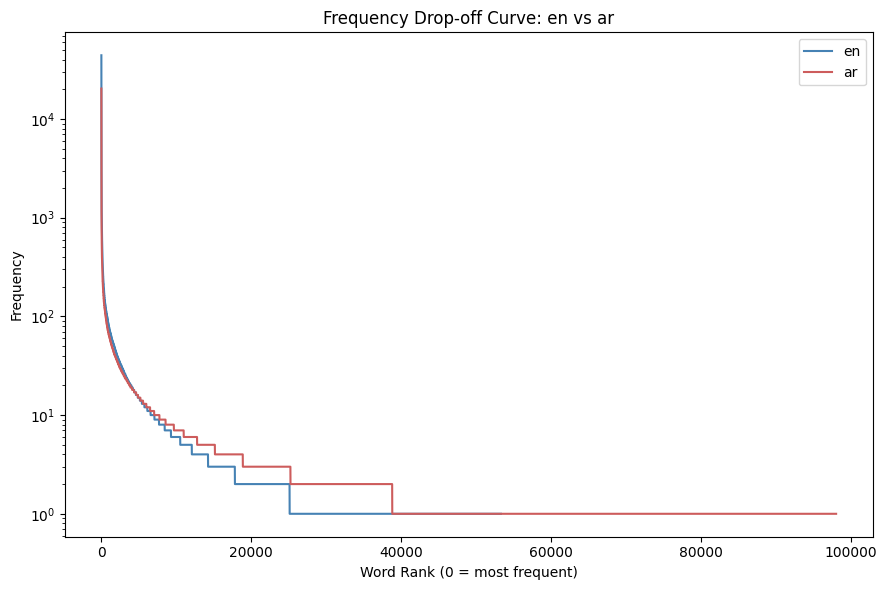

Saved comparison chart -> outputs/comparison_frequency_curve_en_vs_ar.png

All done! Check the outputs folder for CSVs and charts.


In [14]:
if __name__ == "__main__":
    main(CONFIG)